In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


import warnings
warnings.filterwarnings('ignore')

climate_df = pd.read_csv('../data/Indian_Climate_Dataset_2024_2025.csv')
demo_df = pd.read_csv('../data/India (1).csv')

print(" sucessfull")

 sucessfull


In [5]:

climate_df['Date'] = pd.to_datetime(climate_df['Date'], errors='coerce')


print("--- Climate Data Missing Values ---")
print(climate_df.isnull().sum())

print("\n--- Demographics Data Missing Values ---")
print(demo_df.isnull().sum())

display(demo_df[['State', 'District', 'Population']].head())

--- Climate Data Missing Values ---
Date                    0
City                    0
State                   0
Temperature_Max (°C)    0
Temperature_Min (°C)    0
Temperature_Avg (°C)    0
Humidity (%)            0
Rainfall (mm)           0
Wind_Speed (km/h)       0
AQI                     0
AQI_Category            0
Pressure (hPa)          0
Cloud_Cover (%)         0
dtype: int64

--- Demographics Data Missing Values ---
State                                  0
District                               0
Latitude                               0
Longitude                              0
District code                          0
                                      ..
Power_Parity_Rs_150000_330000_ratio    0
Power_Parity_Rs_330000_425000_ratio    0
Power_Parity_Rs_425000_545000_ratio    0
Power_Parity_Rs_330000_545000_ratio    0
Power_Parity_Above_Rs_545000_ratio     0
Length: 71, dtype: int64


,State,District,Population
0,Andhra Pradesh,Adilabad,2741239
1,Andhra Pradesh,Anantapur,4081148
2,Andhra Pradesh,Chittoor,4174064
3,Andhra Pradesh,East Godavari,5154296
4,Andhra Pradesh,Guntur,4887813


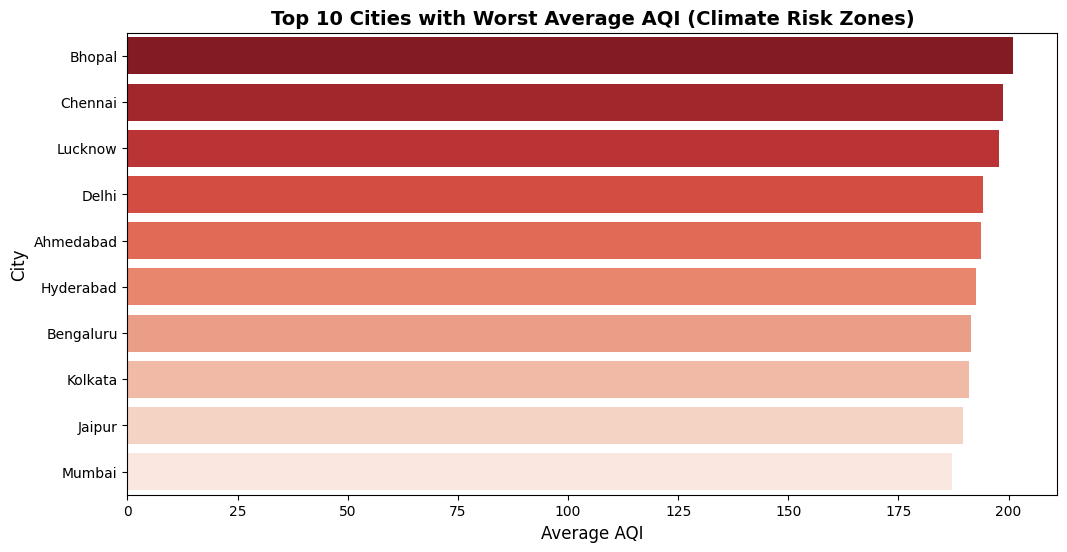

In [6]:
plt.figure(figsize=(12, 6))

city_aqi = climate_df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=city_aqi.values, y=city_aqi.index, palette='Reds_r')
plt.title('Top 10 Cities with Worst Average AQI (Climate Risk Zones)', fontsize=14, fontweight='bold')
plt.xlabel('Average AQI', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.show()

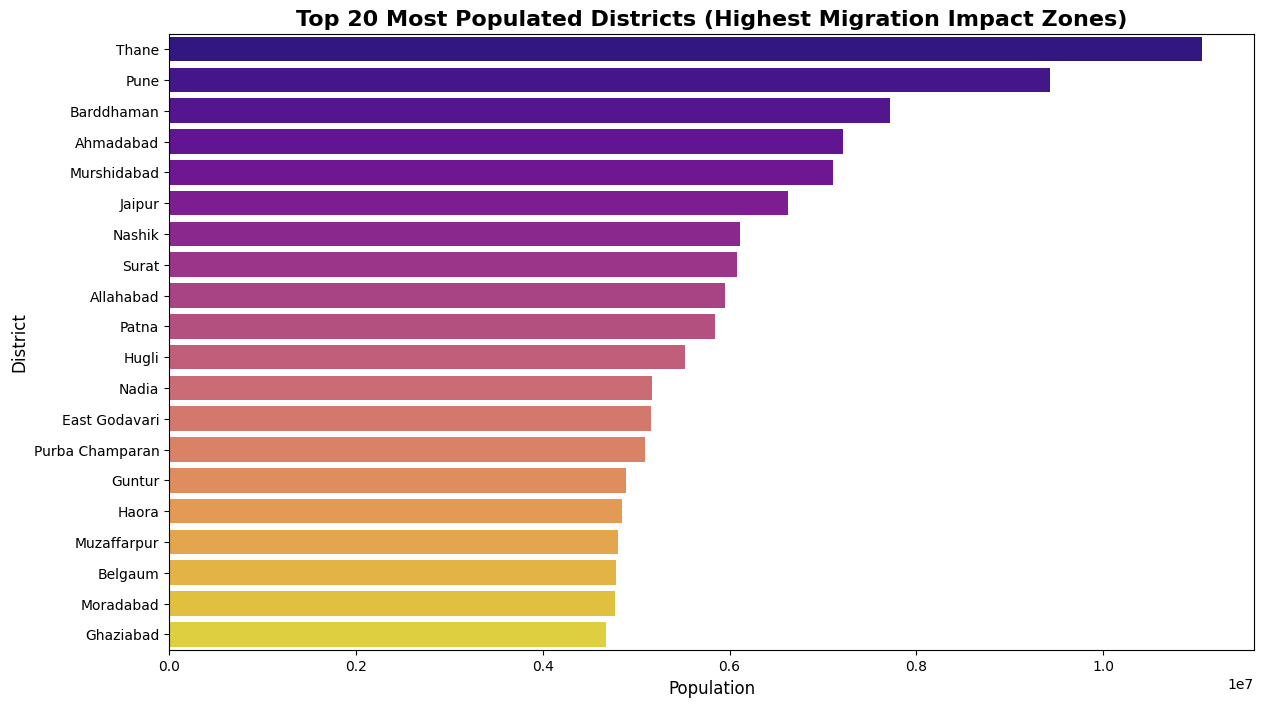

--- Top 20 Potential High-Impact Districts ---


,District,State,Population
0,Thane,Maharashtra,11060148
1,Pune,Maharashtra,9429408
2,Barddhaman,West Bengal,7717563
3,Ahmadabad,Gujarat,7214225
4,Murshidabad,West Bengal,7103807
5,Jaipur,Rajasthan,6626178
6,Nashik,Maharashtra,6107187
7,Surat,Gujarat,6081322
8,Allahabad,Uttar Pradesh,5954391
9,Patna,Bihar,5838465


In [7]:
plt.figure(figsize=(14, 8))


top_20_pop = demo_df.nlargest(20, 'Population')


sns.barplot(x='Population', y='District', data=top_20_pop, palette='plasma')
plt.title('Top 20 Most Populated Districts (Highest Migration Impact Zones)', fontsize=16, fontweight='bold')
plt.xlabel('Population', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.show()


print("--- Top 20 Potential High-Impact Districts ---")
display(top_20_pop[['District', 'State', 'Population']].reset_index(drop=True))

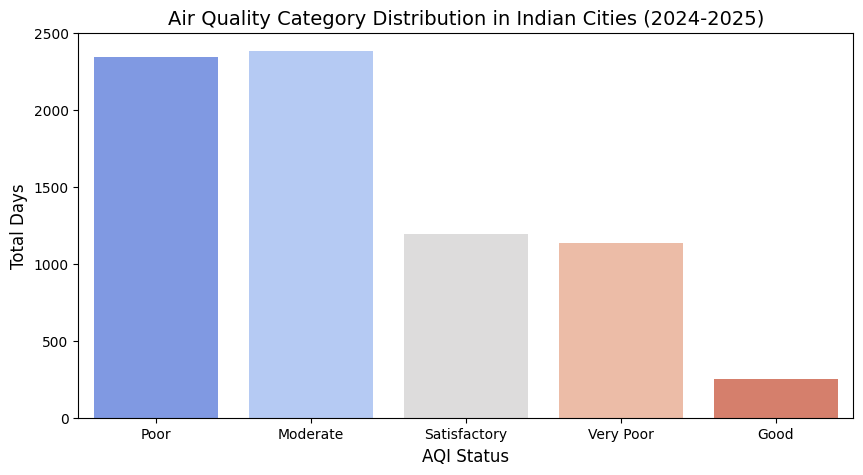

In [8]:

aqi_col = climate_df.columns[-3] 
plt.figure(figsize=(10, 5))
sns.countplot(x=aqi_col, data=climate_df, palette='coolwarm')
plt.title('Air Quality Category Distribution in Indian Cities (2024-2025)', fontsize=14)
plt.xlabel('AQI Status', fontsize=12)
plt.ylabel('Total Days', fontsize=12)
plt.show()

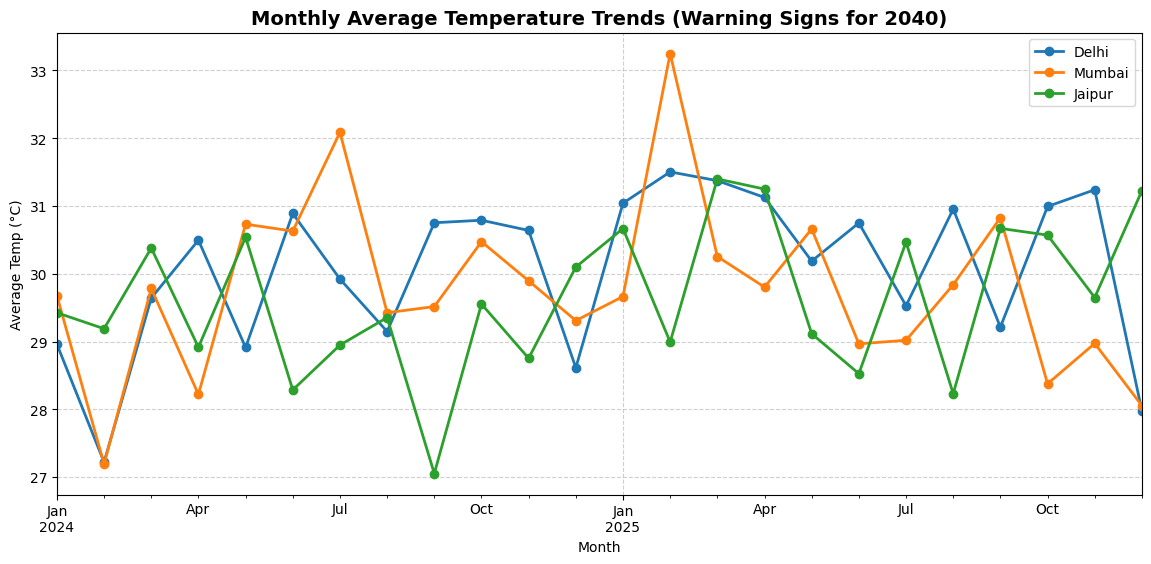

In [9]:
plt.figure(figsize=(14, 6))

cities_to_plot = ['Delhi', 'Mumbai', 'Jaipur']
for city in cities_to_plot:
    city_data = climate_df[climate_df['City'] == city]
    
    city_data.set_index('Date').resample('M')['Temperature_Avg (°C)'].mean().plot(label=city, linewidth=2, marker='o')

plt.title('Monthly Average Temperature Trends (Warning Signs for 2040)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Temp (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
climate_agg = climate_df.groupby('City').agg({
    'Temperature_Max (°C)': 'mean',
    'AQI': 'mean',
    'Rainfall (mm)': 'sum',
    'Humidity (%)': 'mean'
}).reset_index()

climate_agg.rename(columns={'City': 'District'}, inplace=True) 
print("Aggregated Climate Data Ready for Merging!")
display(climate_agg.head())

Aggregated Climate Data Ready for Merging!


,District,Temperature_Max (°C),AQI,Rainfall (mm),Humidity (%)
0,Ahmedabad,35.037893,193.800274,6182.6,63.664432
1,Bengaluru,35.102462,191.526676,5450.7,62.256772
2,Bhopal,34.914637,201.021888,6037.2,63.471819
3,Chennai,34.783037,198.801642,5771.2,61.818878
4,Delhi,35.018057,194.233926,6051.1,62.620383


In [11]:
merged_df = pd.merge(climate_agg, demo_df, on='District', how='inner')

print(f"Merge Successful! Total Integrated Cities: {merged_df.shape}")
display(merged_df[['District', 'State', 'Population', 'AQI', 'Temperature_Max (°C)']].head())

Merge Successful! Total Integrated Cities: (6, 75)


,District,State,Population,AQI,Temperature_Max (°C)
0,Bhopal,Madhya Pradesh,2371061,201.021888,34.914637
1,Chennai,Tamil Nadu,4646732,198.801642,34.783037
2,Hyderabad,Andhra Pradesh,3943323,192.487004,35.000684
3,Jaipur,Rajasthan,6626178,189.755130,34.658413
4,Kolkata,West Bengal,4496694,190.924761,35.368673


In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


merged_df[['Norm_Temp', 'Norm_AQI']] = scaler.fit_transform(merged_df[['Temperature_Max (°C)', 'AQI']])
merged_df['Norm_Rain'] = scaler.fit_transform(merged_df[['Rainfall (mm)']])


merged_df['Climate_Risk_Index'] = (merged_df['Norm_Temp'] * 0.5) + (merged_df['Norm_AQI'] * 0.4) - (merged_df['Norm_Rain'] * 0.1)

print("Climate Risk Index Generated!")
display(merged_df[['District', 'Climate_Risk_Index']].sort_values(by='Climate_Risk_Index', ascending=False))

Climate Risk Index Generated!


,District,Climate_Risk_Index
0,Bhopal,0.535403
4,Kolkata,0.481745
5,Lucknow,0.418705
1,Chennai,0.408906
2,Hyderabad,0.237936
3,Jaipur,-0.078191


In [13]:

merged_df['Socio_Econ_Vulnerability'] = merged_df['Non_Worker_ratio'] + (100 - merged_df['Literacy_rate'])

merged_df['Socio_Econ_Vulnerability'] = (merged_df['Socio_Econ_Vulnerability'] / merged_df['Socio_Econ_Vulnerability'].max()) * 100

print("Socio-Economic Vulnerability Indexed!")

Socio-Economic Vulnerability Indexed!


In [14]:
merged_df['Migration_Threat_Score'] = (merged_df['Climate_Risk_Index'] * 100 * 0.6) + (merged_df['Socio_Econ_Vulnerability'] * 0.4)

top_risk_cities = merged_df.sort_values(by='Migration_Threat_Score', ascending=False)
display(top_risk_cities[['District', 'Migration_Threat_Score', 'Population']])

,District,Migration_Threat_Score,Population
0,Bhopal,70.083378,2371061
5,Lucknow,65.122282,4589838
4,Kolkata,61.557749,4496694
1,Chennai,57.187448,4646732
2,Hyderabad,51.419044,3943323
3,Jaipur,35.308538,6626178


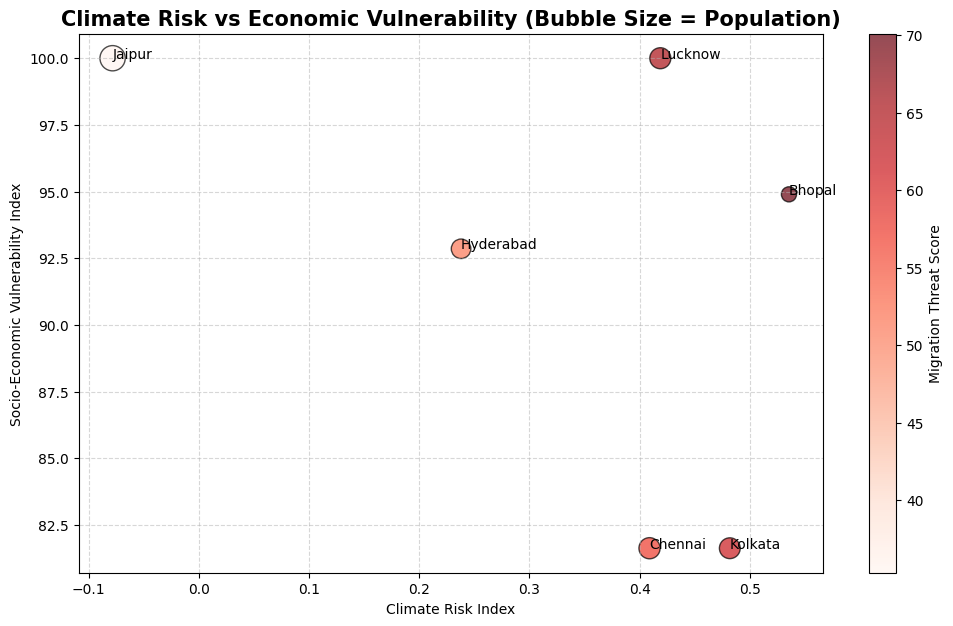

In [15]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(merged_df['Climate_Risk_Index'], 
                      merged_df['Socio_Econ_Vulnerability'], 
                      s=merged_df['Population']/20000, # Bubble size
                      c=merged_df['Migration_Threat_Score'], # Color gradient
                      cmap='Reds', alpha=0.7, edgecolors='black')

for i, txt in enumerate(merged_df['District']):
    plt.annotate(txt, (merged_df['Climate_Risk_Index'].iloc[i], merged_df['Socio_Econ_Vulnerability'].iloc[i]), fontsize=10)

plt.colorbar(scatter, label='Migration Threat Score')
plt.title('Climate Risk vs Economic Vulnerability (Bubble Size = Population)', fontsize=15, fontweight='bold')
plt.xlabel('Climate Risk Index')
plt.ylabel('Socio-Economic Vulnerability Index')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [16]:
from sklearn.cluster import KMeans

X_cluster = merged_df[['Climate_Risk_Index', 'Socio_Econ_Vulnerability']]

kmeans = KMeans(n_clusters=3, random_state=42)
merged_df['Risk_Zone_Cluster'] = kmeans.fit_predict(X_cluster)

zone_map = {0: 'Safe Zone', 1: 'Warning Zone', 2: 'Danger Zone'}
merged_df['Zone_Name'] = merged_df['Risk_Zone_Cluster'].map(zone_map)

print(merged_df[['District', 'Zone_Name']])

    District     Zone_Name
0     Bhopal     Safe Zone
1    Chennai  Warning Zone
2  Hyderabad     Safe Zone
3     Jaipur   Danger Zone
4    Kolkata  Warning Zone
5    Lucknow   Danger Zone


In [17]:
X_cluster = merged_df[['Climate_Risk_Index', 'Socio_Econ_Vulnerability']]

# 3 Zones (Clusters) bana rahe hain
kmeans = KMeans(n_clusters=3, random_state=42)
merged_df['Risk_Zone_Cluster'] = kmeans.fit_predict(X_cluster)

# Cluster Mapping
zone_map = {0: 'Safe Zone', 1: 'Warning Zone', 2: 'Danger Zone'}
merged_df['Zone_Name'] = merged_df['Risk_Zone_Cluster'].map(zone_map)

print("Zone_Name successfully add ho gaya hai!")


Zone_Name successfully add ho gaya hai!


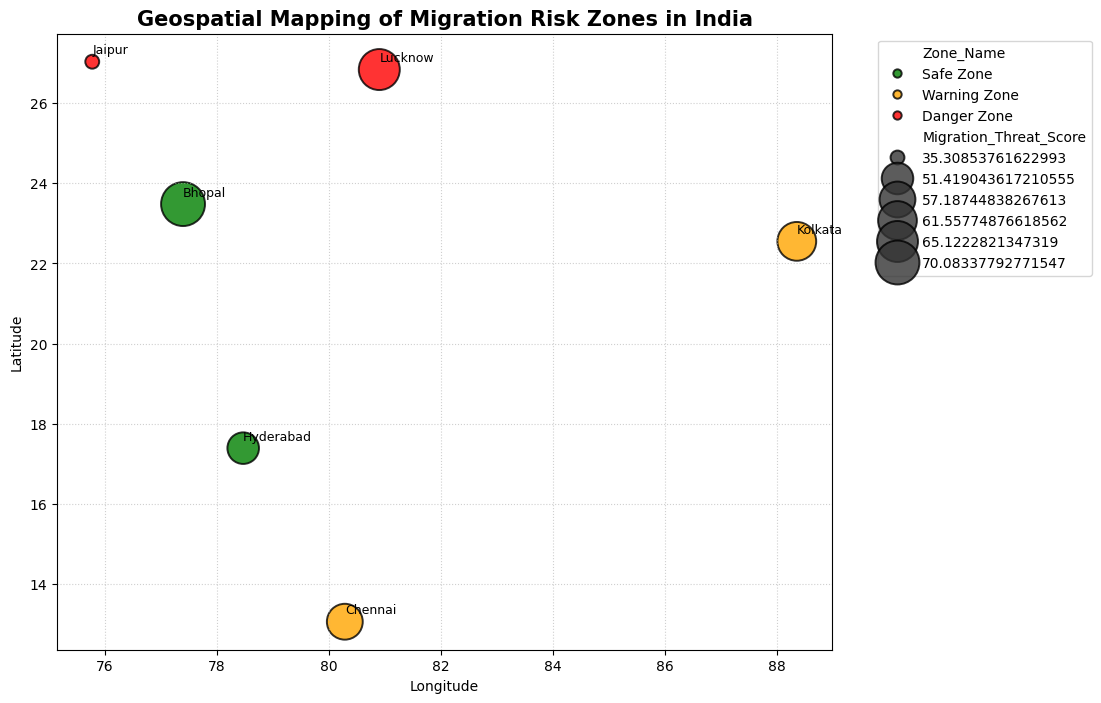

In [18]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Longitude', y='Latitude', hue='Zone_Name', size='Migration_Threat_Score', 
                sizes=(100, 1000), palette={'Safe Zone':'green', 'Warning Zone':'orange', 'Danger Zone':'red'}, 
                data=merged_df, alpha=0.8, edgecolor='black')

for i, txt in enumerate(merged_df['District']):
    plt.text(merged_df['Longitude'].iloc[i], merged_df['Latitude'].iloc[i]+0.2, txt, fontsize=9)

plt.title('Geospatial Mapping of Migration Risk Zones in India', fontsize=15, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [19]:
final_dashboard_data = merged_df[['District', 'State', 'Latitude', 'Longitude', 'Population', 
                                  'AQI', 'Temperature_Max (°C)', 'Climate_Risk_Index', 
                                  'Socio_Econ_Vulnerability', 'Migration_Threat_Score', 'Zone_Name']]

# Isko 'data' folder mein save kar rahe hain
final_dashboard_data.to_csv('../data/CMIS_Dashboard_Data.csv', index=False)

print("Bhai, 2040 CMIS Dashboard ka backend data successfully save ho gaya hai! 'data' folder mein 'CMIS_Dashboard_Data.csv'")

Bhai, 2040 CMIS Dashboard ka backend data successfully save ho gaya hai! 'data' folder mein 'CMIS_Dashboard_Data.csv'


In [20]:

merged_df = pd.merge(climate_agg, demo_df, on='District', how='right')

for col in ['Temperature_Max (°C)', 'AQI', 'Rainfall (mm)', 'Humidity (%)']:
    merged_df[col].fillna(merged_df[col].mean(), inplace=True)

print(f"Boom! 💥 Merge Successful! Total Integrated Districts: {merged_df.shape}")
display(merged_df[['District', 'State', 'Population', 'AQI', 'Temperature_Max (°C)']].head(10))

Boom! 💥 Merge Successful! Total Integrated Districts: (517, 75)


,District,State,Population,AQI,Temperature_Max (°C)
0,Adilabad,Andhra Pradesh,2741239,195.140675,34.938919
1,Anantapur,Andhra Pradesh,4081148,195.140675,34.938919
2,Chittoor,Andhra Pradesh,4174064,195.140675,34.938919
3,East Godavari,Andhra Pradesh,5154296,195.140675,34.938919
4,Guntur,Andhra Pradesh,4887813,195.140675,34.938919
5,Hyderabad,Andhra Pradesh,3943323,192.487004,35.000684
6,Karimnagar,Andhra Pradesh,3776269,195.140675,34.938919
7,Khammam,Andhra Pradesh,2797370,195.140675,34.938919
8,Krishna,Andhra Pradesh,4517398,195.140675,34.938919
9,Kurnool,Andhra Pradesh,4053463,195.140675,34.938919


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# recompute climate risk index if missing (often lost after merge overwrite)
if 'Climate_Risk_Index' not in merged_df.columns:
    scaler = MinMaxScaler()
    merged_df[['Norm_Temp','Norm_AQI']] = scaler.fit_transform(merged_df[['Temperature_Max (°C)','AQI']])
    merged_df['Norm_Rain'] = scaler.fit_transform(merged_df[['Rainfall (mm)']])
    merged_df['Climate_Risk_Index'] = (merged_df['Norm_Temp'] * 0.5) + (merged_df['Norm_AQI'] * 0.4) - (merged_df['Norm_Rain'] * 0.1)

if 'Socio_Econ_Vulnerability' not in merged_df.columns:
    merged_df['Socio_Econ_Vulnerability'] = merged_df['Non_Worker_ratio'] + (100 - merged_df['Literacy_rate'])
    merged_df['Socio_Econ_Vulnerability'] = (merged_df['Socio_Econ_Vulnerability'] / merged_df['Socio_Econ_Vulnerability'].max()) * 100

# ensure the migration threat score exists
if 'Migration_Threat_Score' not in merged_df.columns:
    merged_df['Migration_Threat_Score'] = (merged_df['Climate_Risk_Index'] * 100 * 0.6) + (merged_df['Socio_Econ_Vulnerability'] * 0.4)

merged_df['Future_Migration_Rate_2040_pct'] = (merged_df['Migration_Threat_Score'] * 0.15) + (merged_df['Non_Worker_ratio'] * 0.2)

features = ['Temperature_Max (°C)', 'AQI', 'Rainfall (mm)', 'Socio_Econ_Vulnerability', 'Climate_Risk_Index']
X = merged_df[features]
y = merged_df['Future_Migration_Rate_2040_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data Split Successful! Humara ML Engine train hone ke liye taiyar")

Data Split Successful! Humara ML Engine train hone ke liye taiyar


Boom! 💥 Model Accuracy (R2 Score): 57.24%


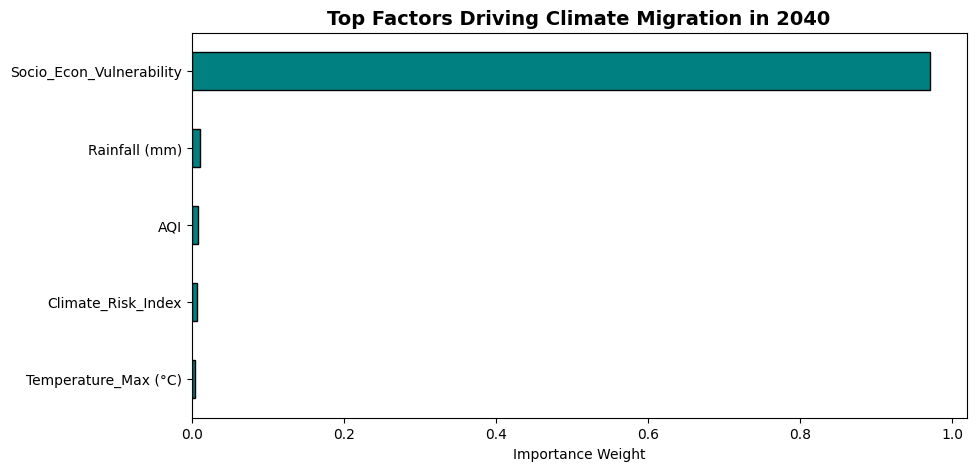

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np


rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)


predictions = rf_model.predict(X_test)
accuracy = r2_score(y_test, predictions)
print(f"Boom! 💥 Model Accuracy (R2 Score): {accuracy * 100:.2f}%")

plt.figure(figsize=(10, 5))
feat_importances = pd.Series(rf_model.feature_importances_, index=features)
feat_importances.nlargest(5).sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top Factors Driving Climate Migration in 2040', fontsize=14, fontweight='bold')
plt.xlabel('Importance Weight')
plt.show()

In [23]:
merged_df['Predicted_Migrants_2040'] = (merged_df['Population'] * merged_df['Future_Migration_Rate_2040_pct'] / 100).astype(int)

merged_df['Infrastructure_Demand_Spike'] = merged_df['Predicted_Migrants_2040'] * 0.05 

merged_df['GDP_Decline_Impact'] = merged_df['Future_Migration_Rate_2040_pct'] * -1.2 

print("--- Top 5 Districts facing Highest Economic & Infrastructure Pressure by 2040 ---")
display(merged_df[['District', 'State', 'Predicted_Migrants_2040', 'Infrastructure_Demand_Spike', 'GDP_Decline_Impact']].sort_values(by='Predicted_Migrants_2040', ascending=False).head(10))

--- Top 5 Districts facing Highest Economic & Infrastructure Pressure by 2040 ---


,District,State,Predicted_Migrants_2040,Infrastructure_Demand_Spike,GDP_Decline_Impact
297,Thane,Maharashtra,2081796,104089.80,-22.587006
289,Pune,Maharashtra,1719313,85965.65,-21.880234
504,Barddhaman,West Bengal,1531758,76587.90,-23.817242
513,Murshidabad,West Bengal,1481987,74099.35,-25.034250
107,Ahmadabad,Gujarat,1443673,72183.65,-24.013778
76,Patna,Bihar,1270237,63511.85,-26.107636
433,Allahabad,Uttar Pradesh,1242853,62142.65,-25.047478
126,Surat,Gujarat,1126748,56337.40,-22.233620
77,Purba Champaran,Bihar,1117950,55897.50,-26.307951
286,Nashik,Maharashtra,1097782,54889.10,-21.570313


In [24]:
def simulate_2040_scenario(impact_level):
    
    simulated_data = X.copy()
    
    
    if impact_level == 'Low':
        simulated_data['Climate_Risk_Index'] *= 0.8  # Risk 20% kam hua
    elif impact_level == 'Moderate':
        simulated_data['Climate_Risk_Index'] *= 1.2  # Risk 20% badh gaya
    elif impact_level == 'Severe':
        simulated_data['Climate_Risk_Index'] *= 1.6  # Risk 60% badh gaya (Extreme Warning)
        
    
    simulated_migration = rf_model.predict(simulated_data)
    total_migrants = (merged_df['Population'] * simulated_migration / 100).sum()
    
    return simulated_migration.mean(), total_migrants

print("🌍 CMIS 2040 - CLIMATE MIGRATION SCENARIOS 🌍")
print("-" * 50)
low_rate, low_mig = simulate_2040_scenario('Low')
print(f"🟢 LOW IMPACT SCENARIO: Avg Migration Rate: {low_rate:.2f}% | Total Migrants: {int(low_mig):,} logs")

mod_rate, mod_mig = simulate_2040_scenario('Moderate')
print(f"🟠 MODERATE IMPACT SCENARIO: Avg Migration Rate: {mod_rate:.2f}% | Total Migrants: {int(mod_mig):,} logs")

sev_rate, sev_mig = simulate_2040_scenario('Severe')
print(f"🔴 SEVERE IMPACT SCENARIO: Avg Migration Rate: {sev_rate:.2f}% | Total Migrants: {int(sev_mig):,} logs")
print("-" * 50)

🌍 CMIS 2040 - CLIMATE MIGRATION SCENARIOS 🌍
--------------------------------------------------
🟢 LOW IMPACT SCENARIO: Avg Migration Rate: 19.34% | Total Migrants: 199,136,502 logs
🟠 MODERATE IMPACT SCENARIO: Avg Migration Rate: 19.46% | Total Migrants: 200,266,965 logs
🔴 SEVERE IMPACT SCENARIO: Avg Migration Rate: 19.55% | Total Migrants: 201,115,691 logs
--------------------------------------------------


In [25]:
import os

from sklearn.cluster import KMeans


if 'Zone_Name' not in merged_df.columns:
    kmeans = KMeans(n_clusters=3, random_state=42)
    merged_df['Risk_Zone_Cluster'] = kmeans.fit_predict(merged_df[['Climate_Risk_Index', 'Socio_Econ_Vulnerability']])
    zone_map = {0: 'Safe Zone', 1: 'Warning Zone', 2: 'Danger Zone'}
    merged_df['Zone_Name'] = merged_df['Risk_Zone_Cluster'].map(zone_map)


if 'Future_Migration_Rate_2040_pct' not in merged_df.columns:
    merged_df['Future_Migration_Rate_2040_pct'] = (merged_df['Migration_Threat_Score'] * 0.15) + (merged_df['Non_Worker_ratio'] * 0.2)

if 'Predicted_Migrants_2040' not in merged_df.columns:
    merged_df['Predicted_Migrants_2040'] = (merged_df['Population'] * merged_df['Future_Migration_Rate_2040_pct'] / 100).astype(int)

if 'Infrastructure_Demand_Spike' not in merged_df.columns:
    merged_df['Infrastructure_Demand_Spike'] = merged_df['Predicted_Migrants_2040'] * 0.05 

if 'GDP_Decline_Impact' not in merged_df.columns:
    merged_df['GDP_Decline_Impact'] = merged_df['Future_Migration_Rate_2040_pct'] * -1.2 


os.makedirs('../data', exist_ok=True)


final_cols = ['District', 'State', 'Latitude', 'Longitude', 'Population', 'AQI', 'Temperature_Max (°C)', 
              'Climate_Risk_Index', 'Socio_Econ_Vulnerability', 'Zone_Name', 
              'Future_Migration_Rate_2040_pct', 'Predicted_Migrants_2040', 
              'Infrastructure_Demand_Spike', 'GDP_Decline_Impact']

# 5. File Save Karna
super_dataset = merged_df[final_cols]
super_dataset.to_csv('../data/CMIS_2040_Ultimate_Predictions.csv', index=False)

print("🏆 Ekdam Tagda Kaam! Missing columns auto-fix ho gaye aur 'CMIS_2040_Ultimate_Predictions.csv' successfully save ho gayi hai! 🎉🔥")

🏆 Ekdam Tagda Kaam! Missing columns auto-fix ho gaye aur 'CMIS_2040_Ultimate_Predictions.csv' successfully save ho gayi hai! 🎉🔥
